# Observing a flare in a MURaM simulation

This tutorial takes a snapshot of the [Cheung et al. (2018)](https://www.nature.com/articles/s41550-018-0629-3) MURaM flare simulation, synthesises four emission lines that Hinode/EIS has long used to see plasma from one million to twenty million kelvin, and observes them with EUVST-SW: the intensity, the Doppler velocity and the velocity precision of each.

The lines are Fe X 184.537, Fe XIV 211.317, Ca XVII 192.858 and Fe XXIV 192.028, formed at about 1, 2, 6 and 20 MK, so between them they see the quiet corona, the active region loops and the flare itself.

## Before you start

| Resource | Needed |
| --- | --- |
| Download | 1.2 GB of simulation data |
| Disk | about 25 GB, mostly for the synthesis file |
| Memory | peaks near 150 GB |
| Wall clock | about two hours on 64 cores, and the download on top; the four instrument runs of 200 Monte Carlo iterations are most of it |

Contribution functions come from CHIANTI through [fiasco](https://fiasco.readthedocs.io/), which builds a local HDF5 copy of the database the first time it is used.

In [1]:
import astropy.units as u
import dill
import matplotlib.pyplot as plt
import numpy as np

from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from pathlib import Path
from sunpy.map import Map

from euvst_response import (
    load_instrument_response_results,
    get_results_for_combination,
    create_sunpy_maps_from_combo,
    summary_table,
)

## 1. Get the simulation snapshot

The MURaM simulation is available at [purl.stanford.edu/dv883vb9686](https://purl.stanford.edu/dv883vb9686). It follows an active region through a flare: snapshot `0300000` is at t = 28,451 s, about four minutes after the eruption begins, when hot loops fill the box.

An optically thin calculation needs the temperature, density, and velocity along the line of sight. In this case, that is the vertical velocity.

| File | Quantity | Unit |
| --- | --- | --- |
| `eosT.0300000` | temperature | K |
| `result_prim_0.0300000` | density | g/cm^3 |
| `result_prim_2.0300000` | vertical velocity | cm/s |

In [2]:
import subprocess

BASE = "https://stacks.stanford.edu/file/druid:dv883vb9686"
SNAPSHOT = "0300000"

files = {
    "temp": f"eosT.{SNAPSHOT}",
    "rho": f"result_prim_0.{SNAPSHOT}",
    "vz": f"result_prim_2.{SNAPSHOT}",
}

for folder, name in files.items():
    path = Path("data/atmosphere") / folder / name
    path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["curl", "-sS", "-L", "-o", str(path), f"{BASE}/{name}"], check=True)
    print(f"{name}: {path.stat().st_size} bytes")

eosT.0300000: 402653184 bytes
result_prim_0.0300000: 402653184 bytes
result_prim_2.0300000: 402653184 bytes


> **Which file holds the vertical velocity.** `result_prim_1`, `_2` and `_3` are the three velocity components, but which of them is vertical depends on the run. In this one, the vertical velocity is `result_prim_2`.

### The grid

`--cube-shape` is the order the cells are written in, so `512 768 256` for these files. The `--voxel-d*` options describe the axes after the reader has put them in heliocentric order: `dx` for the 512-cell axis, `dy` for the 256-cell axis, and `dz` for the 768-cell vertical one.

## 2. Synthesise the spectra

This step reads the three cubes, builds the VDEM, introduces the contribution functions, and writes a synthesis file holding a spectrum of each line for every column of the box.

The velocity grid is chosen for the flare. Its resolution, 10 km/s, samples the narrowest thermal profile among the four lines, Fe X at 13 km/s, and is well below the 26 km/s of a detector pixel. Its range, 1000 km/s either way, holds the flows: in this snapshot about a tenth of the emitting plasma in every temperature band moves faster than 300 km/s along the line of sight, and less than a thousandth faster than 1000 km/s, even at 20 MK. Plasma faster than the range falls outside the grid and is left out.

In [3]:
!synthesise-spectra \
  --data-dir ./data/atmosphere \
  --lines Fe10_184.5370 Fe14_211.3170 Ca17_192.8580 Fe24_192.0280 \
  --output-dir ./run/input \
  --output-name muram_flare.pkl \
  --temp-file temp/eosT.0300000 \
  --rho-file rho/result_prim_0.0300000 \
  --vz-file vz/result_prim_2.0300000 \
  --cube-shape 512 768 256 \
  --voxel-dx "0.192 Mm" \
  --voxel-dy "0.192 Mm" \
  --voxel-dz "0.064 Mm" \
  --vel-res "10 km/s" \
  --vel-lim "1000 km/s" \
  --integration-axis z

STATIC MODE - Single timestep synthesis
  Data directory: data/atmosphere
  Cube shape: [512, 768, 256]
  Voxel sizes: 0.192 Mm x 0.192 Mm x 0.064 Mm
  Integration axis: z
  Velocity grid: +/-1000.0 km / s at 10.0 km / s resolution
  Precision: <class 'numpy.float64'>
  Lines: ['Fe10_184.5370', 'Fe14_211.3170', 'Ca17_192.8580', 'Fe24_192.0280']
  Abundance: sun_coronal_2021_chianti

Loading cubes (15.23/540.81 GB)
Electron density from the mass density with 1.1579 u per electron (fully ionised plasma with sun_coronal_2021_chianti abundances)
Computing contribution functions via fiasco (21.76/540.81 GB)
  Parallel: 4 workers for 4 ions
  Fe10_184.5370: requested 184.5370 Angstrom, matched 184.5370 Angstrom (delta=0.0000 Angstrom)
  Fe14_211.3170: requested 211.3170 Angstrom, matched 211.3170 Angstrom (delta=0.0000 Angstrom)
  Ca17_192.8580: requested 192.8580 Angstrom, matched 192.8530 Angstrom (delta=0.0050 Angstrom)
  Fe24_192.0280: requested 192.0280 Angstrom, matched 192.0280 Angstr

Synthesis prints the requested and matched wavelength for every line. A large difference means CHIANTI has no such transition for that ion and a neighbouring one was picked up instead. See [naming spectral lines](../synthesis/#naming-spectral-lines).

Only the lines asked for are synthesised, so each spectrum holds one line. In a real spectrum Fe XXIV 192.028 has Fe XII 192.394 beside it and Ca XVII 192.858 sits between Fe XI 192.813 and O V 192.904; they can be added to `--lines` and fitted as further components.

`--integration-axis z` is the top-down view, and is why only the vertical velocity was needed. A side view (`x` or `y`) integrates through the box horizontally and needs the matching `--vx-file` or `--vy-file` instead.

## 3. The heliocentric intensity maps

These are the simulation atmosphere before the instrument: the emission of each line integrated along the line of sight and across the line profile, at the simulation resolution. The cool lines show the loops around the flare, the hot ones the flare.

In [4]:
LINES = {
    "Fe10_184.5370": "Fe X 184.537",
    "Fe14_211.3170": "Fe XIV 211.317",
    "Ca17_192.8580": "Ca XVII 192.858",
    "Fe24_192.0280": "Fe XXIV 192.028",
}

with open("run/input/muram_flare.pkl", "rb") as f:
    synthesis = dill.load(f)

for name in LINES:
    line_cube = synthesis["line_cubes"][name]
    print(f"{name}: cube shape {line_cube.data.shape}, unit {line_cube.unit}")

Fe10_184.5370: cube shape (256, 512, 201), unit erg / (s sr cm3)
Fe14_211.3170: cube shape (256, 512, 201), unit erg / (s sr cm3)
Ca17_192.8580: cube shape (256, 512, 201), unit erg / (s sr cm3)
Fe24_192.0280: cube shape (256, 512, 201), unit erg / (s sr cm3)


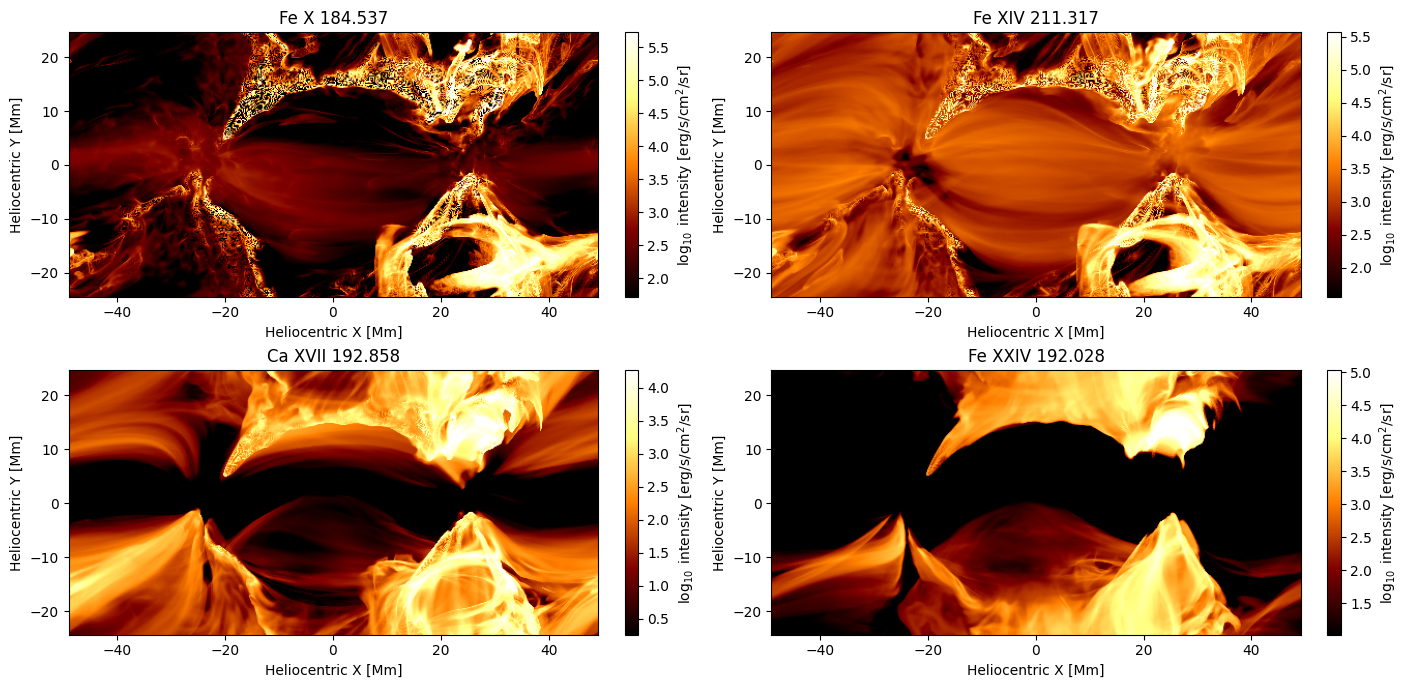

In [5]:
def integrated_intensity(line_cube):
    """The line profile integrated over wavelength, and the map's x and y in Mm."""
    # The cube is indexed (y, x, wavelength) and holds a spectral radiance, so
    # the sum over the last axis needs the wavelength spacing.
    cube = line_cube.to(u.erg / u.s / u.cm**2 / u.sr / u.cm)
    wavelengths = cube.axis_world_coords(-1)[0].to(u.cm)
    d_lambda = np.gradient(wavelengths)
    intensity = (cube.data * d_lambda.value).sum(axis=-1) * u.erg / u.s / u.cm**2 / u.sr
    y = line_cube.axis_world_coords(0)[0].to(u.Mm)
    x = line_cube.axis_world_coords(1)[0].to(u.Mm)
    return intensity, x, y


fig, axes = plt.subplots(2, 2, figsize=(14, 7), layout="compressed")
for ax, (name, label) in zip(axes.flat, LINES.items()):
    intensity, x, y = integrated_intensity(synthesis["line_cubes"][name])
    logged = np.log10(intensity.value, where=intensity.value > 0, out=np.full(intensity.shape, np.nan))
    high = np.nanpercentile(logged, 99.5)
    low = high - 4  # four decades below the brightest columns
    image = ax.imshow(
        logged,
        origin="lower",
        extent=[x[0].value, x[-1].value, y[0].value, y[-1].value],
        cmap="afmhot",
        vmin=low,
        vmax=high,
        aspect="equal",
    )
    ax.set_title(label)
    ax.set_xlabel("Heliocentric X [Mm]")
    ax.set_ylabel("Heliocentric Y [Mm]")
    fig.colorbar(image, ax=ax, label=r"$\log_{10}$ intensity [erg/s/cm$^2$/sr]")
plt.show()


## 4. Simulate the instrument

An instrument run fits one reference line, so the four lines are four runs from the same synthesis file, each with its own configuration. `slit_width: 0.4 arcsec` sets both the slit and the raster step, and `expos: 3 s` is the exposure of the Concept Study Report's flare reconnection case. Both can be given as lists to sweep them (see [the configuration file reference](../instrument-response/#configuration-file)), but here they are single values.

`n_iter: 200` repeats each observation 200 times with independent noise. The spread of the fitted velocities across those repeats is the velocity precision. With no `fitting:` block, each spectrum is fitted with a single Gaussian.

In [6]:
import subprocess

CONFIG = """instrument: SWC
synthesis_file: ./run/input/muram_flare.pkl
reference_line: {line}

n_iter: 200
ncpu: -1
fit_signals: dn

simulation:
  slit_width: 0.4 arcsec
  expos: 3 s
  psf: True

detector:
  ccd_temperature: -60 Celsius

filter:
  c_thickness: 40 angstrom
"""

for name in LINES:
    config = Path("run/input") / f"muram_flare_{name}.yaml"
    config.write_text(CONFIG.format(line=name))
    print(f"==== {LINES[name]}: eclipse --config {config}", flush=True)
    subprocess.run(["eclipse", "--config", str(config)], check=True)

==== Fe X 184.537: eclipse --config run/input/muram_flare_Fe10_184.5370.yaml


/gpfs/data/fs70652/jamesm/solar/wt-tutorials/euvst_response/main.py:472: UserWarning: The SWC PSF is the modelled PSF including simulations and some microroughness measurements. Final PSF will be measured before launch.
  warnings.warn(



  ______ _____ _      _____ _____   _____ ______
 |  ____/ ____| |    |_   _|  __ \ / ____|  ____|
 | |__ | |    | |      | | | |__) | (___ | |__
 |  __|| |    | |      | | |  ___/ \___ \|  __|
 | |___| |____| |____ _| |_| |     ____) | |____
 |______\_____|______|_____|_|    |_____/|______|

ECLIPSE: Emission Calculation and Line Prediction for SOLAR-C EUVST

Contact: James McKevitt (jm2@mssl.ucl.ac.uk). License: Contact for permission to use.

Running instrument response simulation with config: run/input/muram_flare_Fe10_184.5370.yaml
------------------------------------------------------------
Fitting only 'dn' signal (skipping 'photon')

Running 1 parameter combination(s).

Loading atmosphere...
Using 'Fe10_184.5370' as reference line for wavelength grid and metadata...


Resampling spectral axis:   0%|          | 0/1024 [00:00<?, ?batch/s]



Rebinning atmosphere (slit_width=0.4 arcsec, plate_scale=0.159 arcsec / pix, wvl_res=1.6900000000000004e-10 cm / pix)...
  Spectral rebinning to instrument resolution (ny,nx,*nl*)...


...

  Spatially rebinning to plate scale (*ny*,nx,nl) and slit width (ny,*nx*,nl)...
Fitting ground truth cube (offchip_bin_slit=1)...


Monte-Carlo:   0%|          | 0/200 [00:00<?, ?iter/s]


  Ground truth fit failed in 445 of 143988 pixels; their true velocity and width are NaN

--- Combination 1/1 ---
  (single combination - all parameters fixed)
  Calculated dark current: 2.15e+00 electron / (pix s)
  Microroughness sigma: 0.3 nm



Monte-Carlo: 100%|█████████▉| 199/200 [25:26<00:07,  7.61s/iter]


  DN fits: 397220 of 28797600 failed, in 99648 of 143988 pixels, and are left out of the statistics

Saving results to run/result/muram_flare_Fe24_192.0280.pkl
Saved results to run/result/muram_flare_Fe24_192.0280.pkl (512.7 MB)
Software version: 0.9.0  |  Git commit: 611ed204bffcc98a94cd083518808e32642fc162
Instrument response simulation complete! Total combinations: 1


## 5. The maps as observed

Each run's results file holds one combination of the parameters. `summary_table` lists the combinations and the exact parameter names; use it before writing the `get_results_for_combination` call.

In [7]:
results = {name: load_instrument_response_results(f"run/result/muram_flare_{name}.pkl")
           for name in LINES}
summary_table(results["Fe24_192.0280"])

Software version : 0.9.0
Git commit       : 611ed204bffcc98a94cd083518808e32642fc162

detector.ccd_temperature | detector.dark_current    | detector.filter_distance | detector.gain_e_per_dn   | detector.material        | detector.max_dn          | detector.pix_size        | detector.plate_scale_angle | detector.qe_euv          | detector.qe_vis          | detector.read_noise_rms  | detector.wvl_res         | filter.al_thickness      | filter.c_thickness       | filter.mesh_throughput   | filter.oxide_thickness   | filter.table_thickness   | offchip_bin_slit         | simulation.enable_pinholes | simulation.expos         | simulation.instrument    | simulation.n_iter        | simulation.ncpu          | simulation.noise         | simulation.pinhole_positions_spectral | simulation.psf           | simulation.psf_boundary  | simulation.slit_width    | simulation.vis_sl        | telescope.D_ap           | telescope.microroughness_sigma | telescope.psf_params     | telescope.psf_type
--------

In [8]:
maps = {}
for name in LINES:
    combination = get_results_for_combination(results[name], **{
        "simulation.slit_width": 0.4 * u.arcsec,
        "simulation.expos": 3 * u.s,
        "offchip_bin_slit": 1,
    })
    maps[name] = create_sunpy_maps_from_combo(
        combination,
        data_type="dn",
        date_obs="2024-03-20T00:00:00",
    )

print(sorted(maps["Fe24_192.0280"]))

['failed_fits', 'intensity_from_fit', 'intensity_mean', 'intensity_std', 'line_width_from_fit', 'line_width_mean', 'line_width_std', 'total_dn', 'total_photons', 'velocity_err', 'velocity_from_fit', 'velocity_mean', 'velocity_std', 'velocity_true']


Three maps of each line from the same observation: the intensity the detector recorded, the Doppler velocity fitted to it, and the precision of that velocity. Velocity is positive away from the observer, so blue is plasma rising towards the observer above the box and red plasma moving down. The precision is the standard deviation of the fitted velocity over the 200 repeats: small where a line is bright, large where it is faint, so the hot lines are measured well in the flare and the cool lines around it. The velocity is shown only where the precision is within 10 km/s, since elsewhere the fitted value is mostly noise.

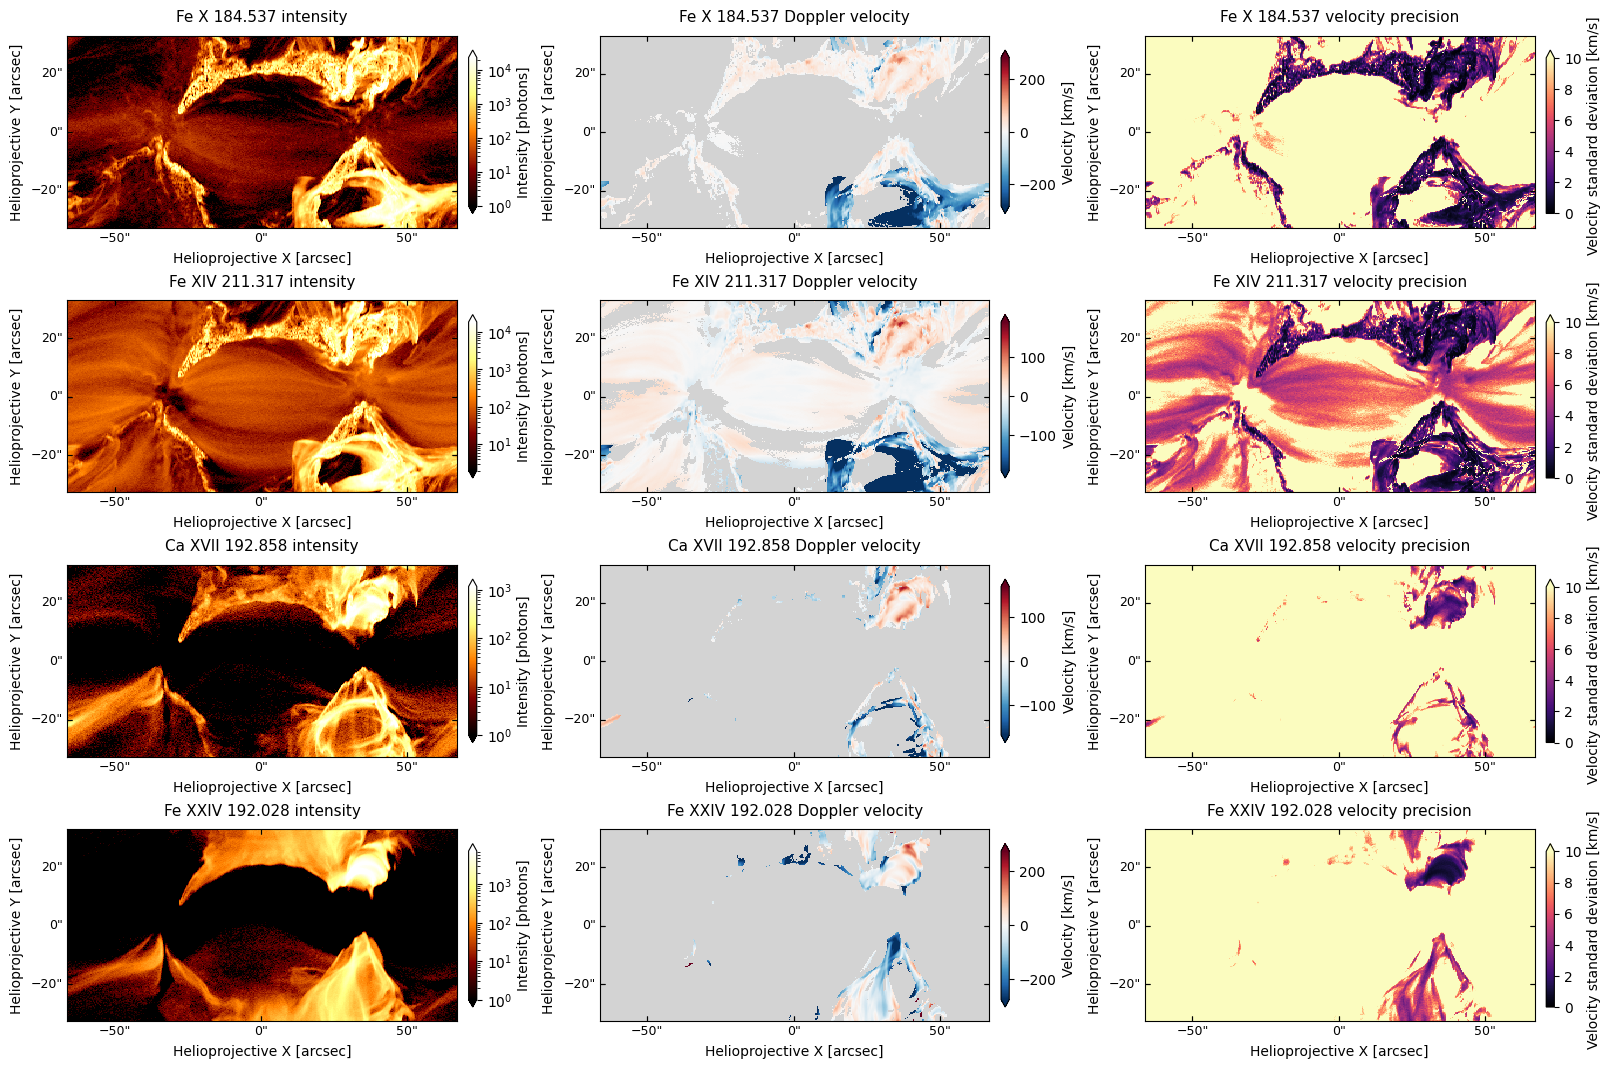

In [9]:
def frame(ax, m):
    """Show the map to 1 arcsec inside its edges, with ticks on every side."""
    ny, nx = m.data.shape
    corners = m.pixel_to_world([0, nx] * u.pix, [0, ny] * u.pix)
    padding = 1 * u.arcsec
    x0, y0 = m.world_to_pixel(SkyCoord(corners.Tx[0] + padding, corners.Ty[0] + padding,
                                       frame=m.coordinate_frame))
    x1, y1 = m.world_to_pixel(SkyCoord(corners.Tx[1] - padding, corners.Ty[1] - padding,
                                       frame=m.coordinate_frame))
    ax.set_xlim(x0.value, x1.value)
    ax.set_ylim(y0.value, y1.value)
    ax.set_frame_on(False)
    ax.grid(False)
    lon, lat = ax.coords
    for coord in (lon, lat):
        coord.set_ticks_visible(True)
        coord.set_ticks_position("all")
    ax.tick_params(axis="both", which="both", direction="in", labelsize=9, pad=3)
    lon.set_axislabel("Helioprojective X [arcsec]", fontsize=10)
    lat.set_axislabel("Helioprojective Y [arcsec]", fontsize=10)


PRECISION_LIMIT = 10  # km/s; velocities are shown where they are measured this well

fig = plt.figure(figsize=(16, 4.4 * len(LINES)), layout="compressed")
for row, (name, label) in enumerate(LINES.items()):
    photons = maps[name]["total_photons"]
    precision = maps[name]["velocity_std"]
    # The velocity map, only where the precision is within the limit.
    measured = precision.data < PRECISION_LIMIT
    velocity = Map(np.where(measured, maps[name]["velocity_mean"].data, np.nan), maps[name]["velocity_mean"].meta, plot_settings=maps[name]["velocity_mean"].plot_settings)

    ax = fig.add_subplot(len(LINES), 3, 3 * row + 1, projection=photons)
    image = photons.plot(axes=ax, annotate=False, autoalign=False)
    low, high = np.nanpercentile(photons.data[photons.data > 0], [1, 99.5])
    image.set_norm(LogNorm(vmin=low, vmax=high))
    image.cmap.set_bad(image.cmap(0))  # columns with no photons at all, drawn as the darkest colour
    frame(ax, photons)
    ax.set_title(f"{label} intensity", fontsize=11, pad=10)
    fig.colorbar(image, ax=ax, orientation="vertical", extend="both", pad=0.03, shrink=0.85).set_label("Intensity [photons]")

    ax = fig.add_subplot(len(LINES), 3, 3 * row + 2, projection=velocity)
    image = velocity.plot(axes=ax, annotate=False, autoalign=False, cmap="RdBu_r")
    limit = np.nanpercentile(np.abs(velocity.data), 95)
    image.set_clim(-limit, limit)
    image.cmap.set_bad("lightgrey")
    frame(ax, velocity)
    ax.set_title(f"{label} Doppler velocity", fontsize=11, pad=10)
    fig.colorbar(image, ax=ax, orientation="vertical", extend="both", pad=0.03, shrink=0.85).set_label("Velocity [km/s]")

    ax = fig.add_subplot(len(LINES), 3, 3 * row + 3, projection=precision)
    image = precision.plot(axes=ax, annotate=False, autoalign=False)
    image.set_clim(0, PRECISION_LIMIT)
    frame(ax, precision)
    ax.set_title(f"{label} velocity precision", fontsize=11, pad=10)
    fig.colorbar(image, ax=ax, orientation="vertical", extend="max", pad=0.03, shrink=0.85).set_label("Velocity standard deviation [km/s]")

plt.show()


`create_sunpy_maps_from_combo` returns more than these three maps. `total_photons` is the signal before the detector and `total_dn` the same after it; `velocity_mean` and `velocity_std` are the mean and standard deviation of the fitted velocity across iterations; `velocity_from_fit` is the first fit of the first iteration, and `velocity_err` its difference from the known truth. They are ordinary SunPy maps, so all the SunPy map functions can be used.

From here, the same snapshot can be observed with a longer exposure or a narrower slit by changing the configuration, the flare followed through the deposit's other snapshots, or the box seen from the side with `--integration-axis x` and the matching velocity file.